In [465]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import os, sys

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.metrics import eval_metrics_2d, metrics_evo


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [466]:
def compare_metrics(dataframes, labels):
    
    
    # Headers
    header = f"{'Metric':<35} | " + " | ".join([f"{label[:15]:^12}" for label in labels])
    print(header)
    print("-" * 95)
    
    # GEt data
    all_metrics = []
    for df in dataframes:
        df = df.iloc[start:end, :]
        # extract
        pred_traj = np.column_stack((df['pred_x'], df['pred_y'], df['pred_theta']))
        gt_traj = np.column_stack((df['gt_x'], df['gt_y'], df['gt_theta']))
        # calc materics
        res = eval_metrics_2d(pred_traj, gt_traj) 
        all_metrics.append(res)
    
    # Kkeys
    metrics_display = {
        "Total Trajectory Length [m]": ("distance", "{:12.4f}"),
        "Total Rotation Length [rad]": ("rotation", "{:12.4f}"),
        "ATE (Absolute Traj. Err) [m]": ("ate_rmse", "{:12.4f}"),
        "Final Position Drift [m]": ("final_drift_m", "{:12.4f}"),
        "RTE (Relative Trans. Err) [%]": ("rte_perc", "{:12.2f}"),
        "ARE (Absolute Rot. Err) [rad]": ("are_rmse", "{:12.4f}"),
        "Final Rotation Drift [rad]": ("final_rot_drift", "{:12.4f}"),
        "RRE (Relative Rot. Err) [%]": ("rre_perc", "{:12.2f}")
    }

    print("\n" + "=" * 95)
    print(f"{'Odometry Evaluation Metrics - Comparison':^95}")
    print("=" * 95)
        
    
    for display_name, (dict_key, fmt) in metrics_display.items():
        if "Total" in display_name:
            print("-" * 95) 
            
        row_str = f"{display_name:<35} | "
        for metrics in all_metrics:
            val = metrics.get(dict_key, 0.0)
            row_str += fmt.format(val) + " | "
        print(row_str[:-3])
        
    print("=" * 95 + "\n")

In [467]:
def compare_trajectory_2d(dataframes, labels):
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    
    # gt
    gt_df = dataframes[0].iloc[start:end, :]
    ax.plot(gt_df['gt_x'], gt_df['gt_y'], label='GT', 
            color='black', linewidth=3, linestyle='--', zorder=10)
    
    # start
    ax.plot(gt_df['gt_x'].iloc[0], gt_df['gt_y'].iloc[0], label='Start', 
            color='green', marker='o', markersize=8, zorder=11, linestyle='None')
    
    # colors list
    colors =  ['red', 'blue', 'green', 'purple', 'orange']
    
    # draw trajectory
    for i, (df, label) in enumerate(zip(dataframes, labels)):
        df = df.iloc[start:end, :]
        color = colors[i % len(colors)]
        ax.plot(df['pred_x'], df['pred_y'], label=f'{label}', 
                color=color, linewidth=2, zorder=5+i, alpha=0.8)

    # styles
    ax.minorticks_on()
    ax.grid(visible=True, which='major', color='#999999', linestyle='-', alpha=0.4)
    ax.grid(visible=True, which='minor', color='#cccccc', linestyle='--', alpha=0.2)

    ax.set_title('', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('X [m]', fontsize=12, labelpad=10)
    ax.set_ylabel('Y [m]', fontsize=12, labelpad=10)
    ax.set_aspect('equal', adjustable='box') # force equal proportions

    ax.legend(loc='best', frameon=True, facecolor='white', edgecolor='#e0e0e0', framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')

    plt.tight_layout()
    plt.show()

In [468]:
def compare_trajectory_3d(dataframes, labels):
  
    fig = go.Figure()
    
    #  get gt
    gt_df = dataframes[0].iloc[start:end, :]
    
    # get depth 
    z_gt = gt_df['depth'] if 'depth' in gt_df.columns and not gt_df['depth'].isna().all() else np.zeros_like(gt_df['gt_x'])

    # gt
    fig.add_trace(go.Scatter3d(
        x=gt_df['gt_x'],
        y=gt_df['gt_y'],
        z=z_gt,
        mode='lines',
        name='GT',
        line=dict(color='black', width=6)
    ))
    
    # start pt
    fig.add_trace(go.Scatter3d(
        x=[gt_df['gt_x'].iloc[0]],
        y=[gt_df['gt_y'].iloc[0]],
        z=[z_gt.iloc[0]],
        mode='markers',
        name='Start',
        marker=dict(color='green', size=8)
    ))

    # color list 
    plotly_colors = ['red', 'blue', 'green', 'purple', 'orange']

    # trajectories
    for i, (df, label) in enumerate(zip(dataframes, labels)):
        df = df.iloc[start:end, :]
        z_pred = df['depth'] if 'depth' in df.columns and not df['depth'].isna().all() else np.zeros_like(df['pred_x'])
        color = plotly_colors[i % len(plotly_colors)]
        
        fig.add_trace(go.Scatter3d(
            x=df['pred_x'],
            y=df['pred_y'],
            z=z_pred,
            mode='lines',
            name=f'{label}',
            line=dict(color=color, width=4)
        ))

    # setup layouts
    fig.update_layout(
        # title=dict(text="Zestawienie trajektorii odometrii (3D)", font=dict(size=18)),
        scene=dict(
            xaxis_title='X [m]',
            yaxis_title='Y [m]',
            zaxis_title='Z [m]',
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=0.4) # set flatten z to clearer view
        ),
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01,
            bgcolor="rgba(255, 255, 255, 0.8)"
        ),
        width=1000,
        height=700,
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

In [469]:
def quality_comparision(dataframes, labels):

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=100)
    # colors = ['#d62728', "#1c49ff", "#00a140", "#aa5b00", "#8a006f"]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, (df, label) in enumerate(zip(dataframes, labels)):
        df = df.iloc[start:end, :]
        color = colors[i % len(colors)]
        frames = np.arange(len(df['confidence'])) / len(df['confidence']) * 100
     
        axs[0].plot(frames, df['inliers_abs'], label=label, color=color, linewidth=1.5, alpha=0.8)
        axs[1].plot(frames, df['inliers_ratio'] * 100, label=label, color=color, linewidth=1.5, alpha=0.8) # *100 dla procentów

    # --- Confidence ---
    axs[0].set_title('Bezwzględna ilość spójnych punktów', fontsize=13, fontweight='bold')
    axs[0].set_ylabel('[-]', fontsize=11)
    axs[0].legend(loc='best', frameon=True, facecolor='white', framealpha=0.9)
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # --- Inliers ---
    axs[1].set_title('Stosunek spójnych punków RANSAC do całkowitej liczby punktów', fontsize=13, fontweight='bold')
    axs[1].set_ylabel('[%]', fontsize=11)
    axs[1].set_xlabel('Przebyta trasa [%]', fontsize=11)
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # Layout
    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
    plt.tight_layout()
    plt.show()

In [470]:
def estimation_deviation_compare(dataframes, labels):

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi=100)
    
   
    data_x = [df['est_std_x'].iloc[start:end].dropna() for df in dataframes]
    data_y = [df['est_std_y'].iloc[start:end].dropna() for df in dataframes]
    data_theta = [df['est_std_theta'].iloc[start:end].dropna() for df in dataframes]


    box_props = dict(patch_artist=True, boxprops=dict(facecolor='#1f77b4', color='black', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2), 
                     flierprops=dict(marker='.', markerfacecolor='gray', markersize=4, alpha=0.5))

    # --- Boxplot X ---
    axs[0].boxplot(data_x, labels=labels, **box_props)
    axs[0].set_title('Rozrzut w oknie: X (Ruch w przód)', fontsize=12, fontweight='bold')
    axs[0].set_ylabel('Odchylenie standardowe [m]')

    # --- Boxplot Y ---
    axs[1].boxplot(data_y, labels=labels, **box_props)
    axs[1].set_title('Rozrzut w oknie: Y (Ruch boczny)', fontsize=12, fontweight='bold')
    axs[1].set_ylabel('Odchylenie standardowe [m]')

    # --- Boxplot Yaw ---
    axs[2].boxplot(data_theta, labels=labels, **box_props)
    axs[2].set_title('Rozrzut w oknie: Kąt Yaw (Kierunek)', fontsize=12, fontweight='bold')
    axs[2].set_ylabel('Odchylenie standardowe [rad]')

    # Kosmetyka dla wszystkich subplotów
    for ax in axs:
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
        ax.grid(False, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Pochylenie etykiet, gdyby były zbyt długie
        ax.tick_params(axis='x', rotation=15)

    plt.suptitle('Porównanie spójności estymat wewnątrz okna czasowego', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

In [471]:
def step_error_comparision(dataframes, labels):
   
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
    
    # --- Przygotowanie danych statystycznych ---
    # Błąd translacji (Euklidesowy błąd kroku z X i Y)
    trans_errors = [
        np.sqrt((df['err_step_dx'].iloc[start:end])**2 + (df['err_step_dy'].iloc[start:end])**2).dropna() 
        for df in dataframes
    ]
    
    # Błąd rotacji (Absolutna wartość błędu zmiany kąta)
    rot_errors = [
        np.abs(df['err_step_dtheta'].iloc[start:end]).dropna() 
        for df in dataframes
    ]

    # Ustawienia stylu dla wykresów pudełkowych (Boxplots)
    box_props = dict(
        patch_artist=True, 
        boxprops=dict(facecolor="#2ca02c", color='black', alpha=0.3), # Używamy np. zielonego tła
        medianprops=dict(color='red', linewidth=2), 
        flierprops=dict(marker='.', markerfacecolor='gray', markersize=4, alpha=0.5)
    )

    # --- Subplot 1: Błąd lokalnej translacji ---
    axs[0].boxplot(trans_errors, labels=labels, showfliers=False, **box_props) 
    axs[0].set_title('Względny lokalny błąd translacji', fontsize=13, fontweight='bold')
    axs[0].set_ylabel('Błąd przesunięcia 2D [m]', fontsize=11)

    # --- Subplot 2: Błąd lokalnej rotacji ---
    # Dodano showfliers=False
    axs[1].boxplot(rot_errors, labels=labels, showfliers=False, **box_props)
    axs[1].set_title('Względny lokalny błąd rotacji', fontsize=13, fontweight='bold')
    axs[1].set_ylabel('Błąd obrotu [rad]', fontsize=11)
    # Kosmetyka dla wszystkich subplotów
    for ax in axs:
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
        ax.grid(False, axis='x')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Pochylenie etykiet na osi X, jeśli nazwy modeli są długie
        ax.tick_params(axis='x', rotation=15)

    # Główny tytuł
    plt.suptitle('Zestawienie stabilności lokalnej modeli (błąd na jeden krok)', 
                 fontsize=16, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()

In [472]:
# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# # seq_pth = 'SonarOdometryDataset/selfsupervised/val/seq_15'

# # root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# seq1_pth = 'SonarOdometryDataset/selfsupervised/val/seq_15'
# # seq2_pth = 'SonarOdometryDataset/supervised/val/seq_14'

# # root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017'

# traj1_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_small_noise.csv')
# traj2_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_small_noise_artefacts.csv')
# traj3_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_mid_noise.csv')
# traj4_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_mid_noise_artefacts.csv')
# traj5_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_big_noise_big_artefacts.csv')


# # traj1_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise.csv')
# # traj2_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise_nobackend.csv')
# # traj3_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise_windowsize_5.csv')
# # traj4_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise_smaller_step.csv')

# # traj1_pth = os.path.join(root_dir, 'eval_6.csv')

# traj1 = pd.read_csv(traj1_pth)
# traj2 = pd.read_csv(traj2_pth)
# traj3 = pd.read_csv(traj3_pth)
# traj4 = pd.read_csv(traj4_pth)
# traj5 = pd.read_csv(traj5_pth)

# labels = [r'Szum 100%, brak artefaktów', r'Szum 100%', r'Szum 120%', r'Szum 150%', r'Szum 170%']
# # labels = ['Brak okna', 'Rozmiar okna: 3', 'Rozmiar okna: 5']
# # traj = [traj1]
# # labels = ['Predykcja']
# traj = [traj1, traj3, traj4, traj2, traj5]
# # traj = [traj2, traj4, traj3]

# start = 0
# end = -20


In [473]:
# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# seq_pth = 'SonarOdometryDataset/selfsupervised/val/seq_15'

# root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry'
# seq1_pth = 'SonarOdometryDataset/selfsupervised/val/seq_15'
# seq2_pth = 'SonarOdometryDataset/supervised/val/seq_14'

root_dir = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/data/aracati2017'

# traj1_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_small_noise.csv')
# traj2_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_small_noise_artefacts.csv')
# traj3_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_mid_noise.csv')
# traj4_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_mid_noise_artefacts.csv')
# traj5_pth = os.path.join(root_dir, seq1_pth, 'results/noise_comparie/eval_seq15_big_noise_big_artefacts.csv')


# traj1_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise.csv')
# traj2_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise_nobackend.csv')
# traj3_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise_windowsize_5.csv')
# traj4_pth = os.path.join(root_dir, seq2_pth, 'results/eval_std_noise_smaller_step.csv')

traj1_pth = os.path.join(root_dir, 'eval_5_gt_yaw.csv')

traj1 = pd.read_csv(traj1_pth)
# traj2 = pd.read_csv(traj2_pth)
# traj3 = pd.read_csv(traj3_pth)
# traj4 = pd.read_csv(traj4_pth)
# traj5 = pd.read_csv(traj5_pth)

# labels = [r'Szum 100%, brak artefaktów', r'Szum 100%', r'Szum 120%', r'Szum 150%', r'Szum 170%']
# labels = ['Brak okna', 'Rozmiar okna: 3', 'Rozmiar okna: 5']
traj = [traj1]
labels = ['Predykcja']
# traj = [traj2, traj4, traj3, traj4, traj5]
# traj = [traj2, traj4, traj3]

start = 0
end = -1

In [474]:
for name, seq in zip(labels, traj):

    print('='*97)
    print(' '*40, name)
    metrics_evo(seq, rpe_percent = 10.0)

                                         Predykcja
                                   ODOMETRY EVALUATION METRICS                                   
 Trajectory Length (GT) : 253.83 m
 RPE Evaluation Step    : 10.0% of trajectory length (25.38 m)
-------------------------------------------------------------------------------------------------
METRIC [UNIT]                    |     RMSE |     MEAN |   MEDIAN |      MIN |      MAX |      STD
-------------------------------------------------------------------------------------------------
APE Translation (ATE) [m]        |   8.8000 |   7.7967 |   7.1087 |   0.0000 |  17.4110 |   4.0807
APE Rotation [rad]               |   0.0000 |   0.0000 |   0.0000 |   0.0000 |   0.0000 |   0.0000
RPE Translation (d=25.4m) [m]    |   7.7398 |   7.4183 |   8.4618 |   3.5435 |   9.9881 |   2.2075
RPE Rotation (d=25.4m) [rad]     |   0.0000 |   0.0000 |   0.0000 |   0.0000 |   0.0000 |   0.0000
--------------------------------------------------------------

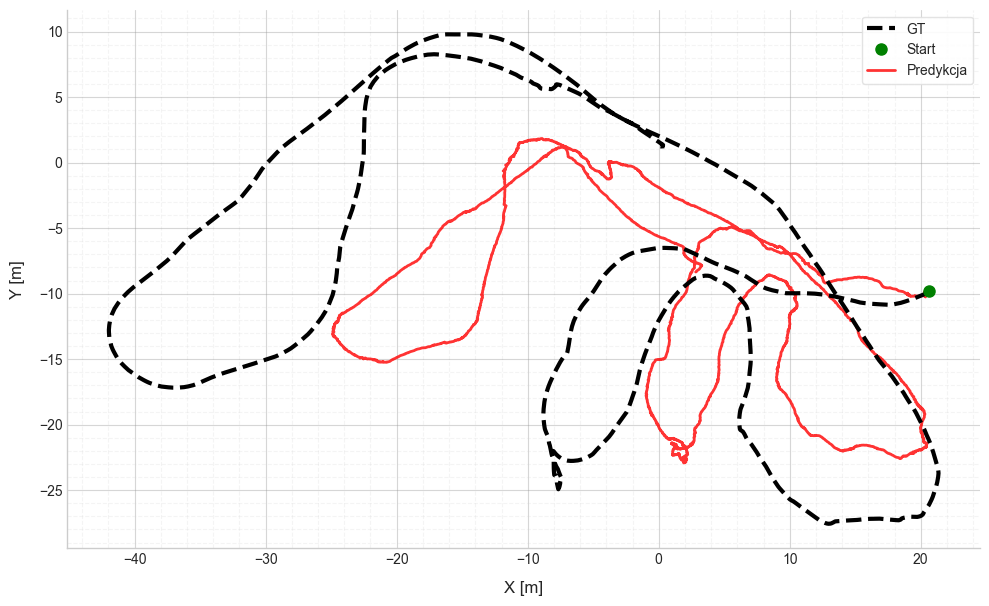

In [475]:
compare_trajectory_2d(traj, labels)

In [476]:
compare_trajectory_3d(traj, labels)

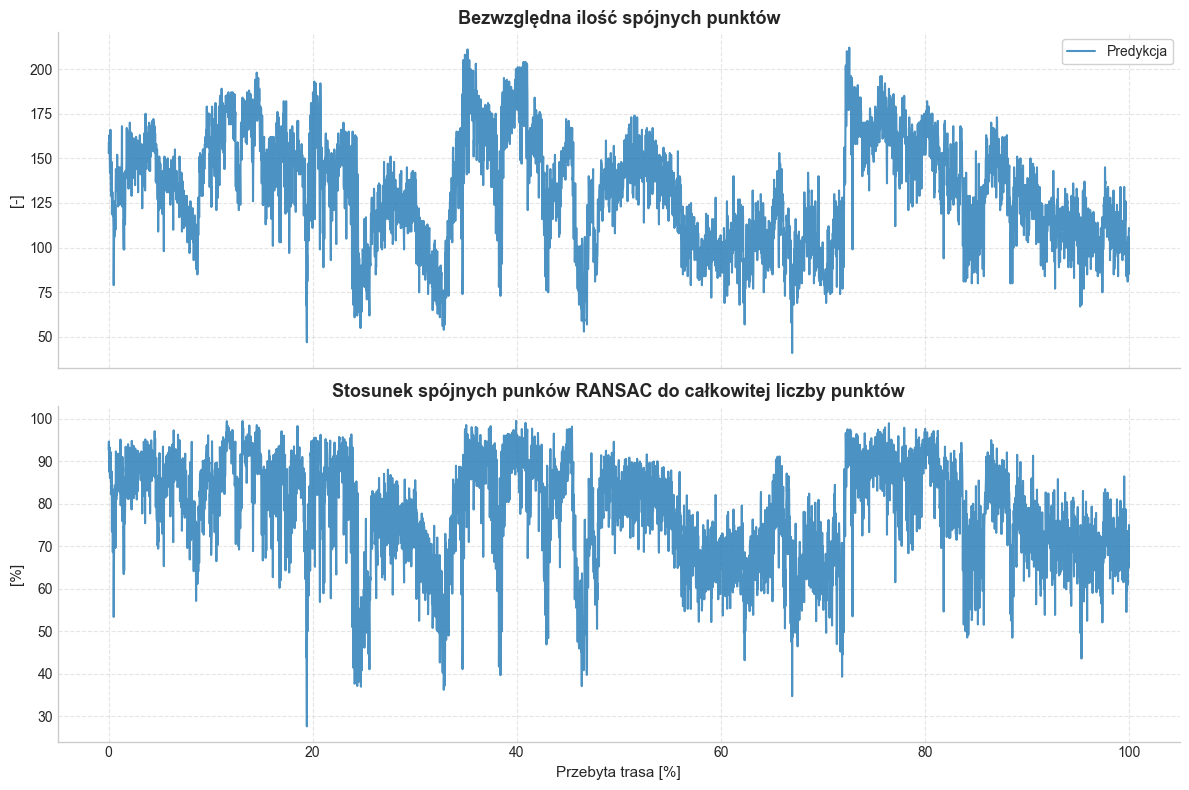

In [477]:
quality_comparision(traj, labels)

C:\Users\janis\AppData\Local\Temp\ipykernel_26788\360592484.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0].boxplot(trans_errors, labels=labels, showfliers=False, **box_props)
C:\Users\janis\AppData\Local\Temp\ipykernel_26788\360592484.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1].boxplot(rot_errors, labels=labels, showfliers=False, **box_props)


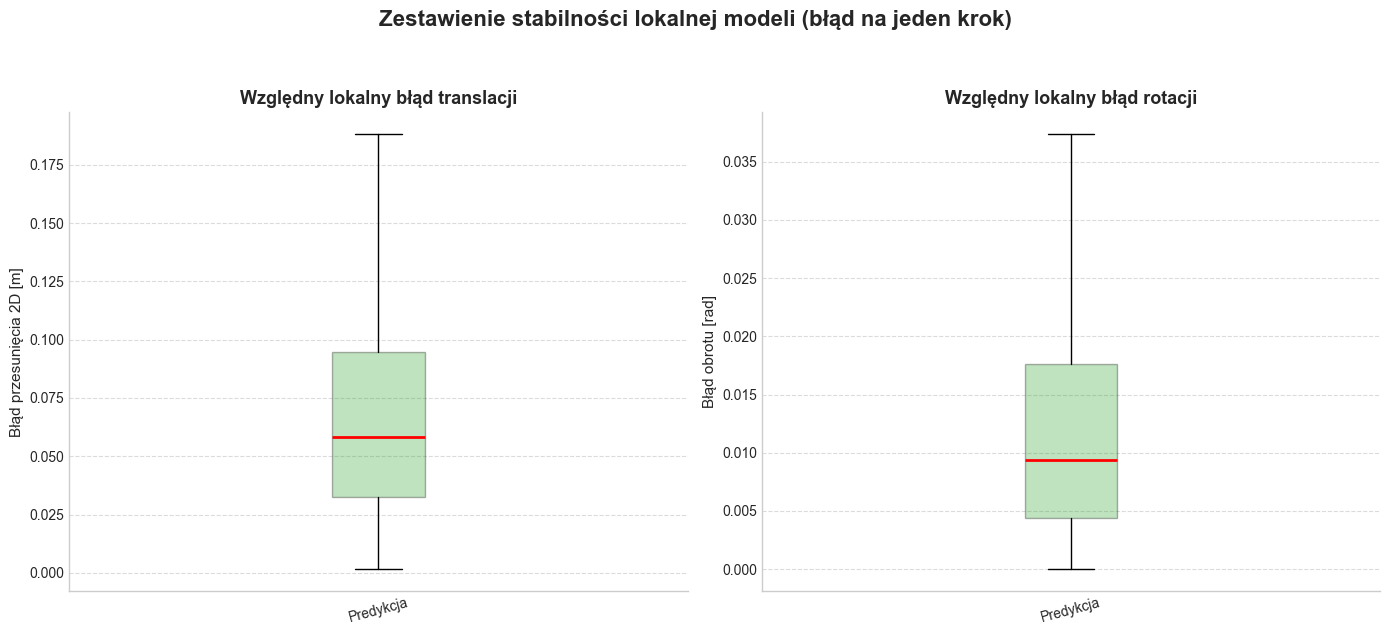

In [478]:
step_error_comparision(traj, labels)

STATYSTYKI BŁĘDU KROKOWEGO (PER STEP):
Oś dX (Przesunięcie w przód):
  Średnia (MAE) : 0.04818 m
  Mediana       : 0.03328 m
  Odchyl. (STD) : 0.05386 m

Oś dY (Przesunięcie bocznie):
  Średnia (MAE) : 0.03621 m
  Mediana       : 0.03093 m
  Odchyl. (STD) : 0.04487 m

Oś dYaw (Kąt obrotu):
  Średnia (MAE) : 0.01302 rad
  Mediana       : 0.00934 rad
  Odchyl. (STD) : 0.01788 rad


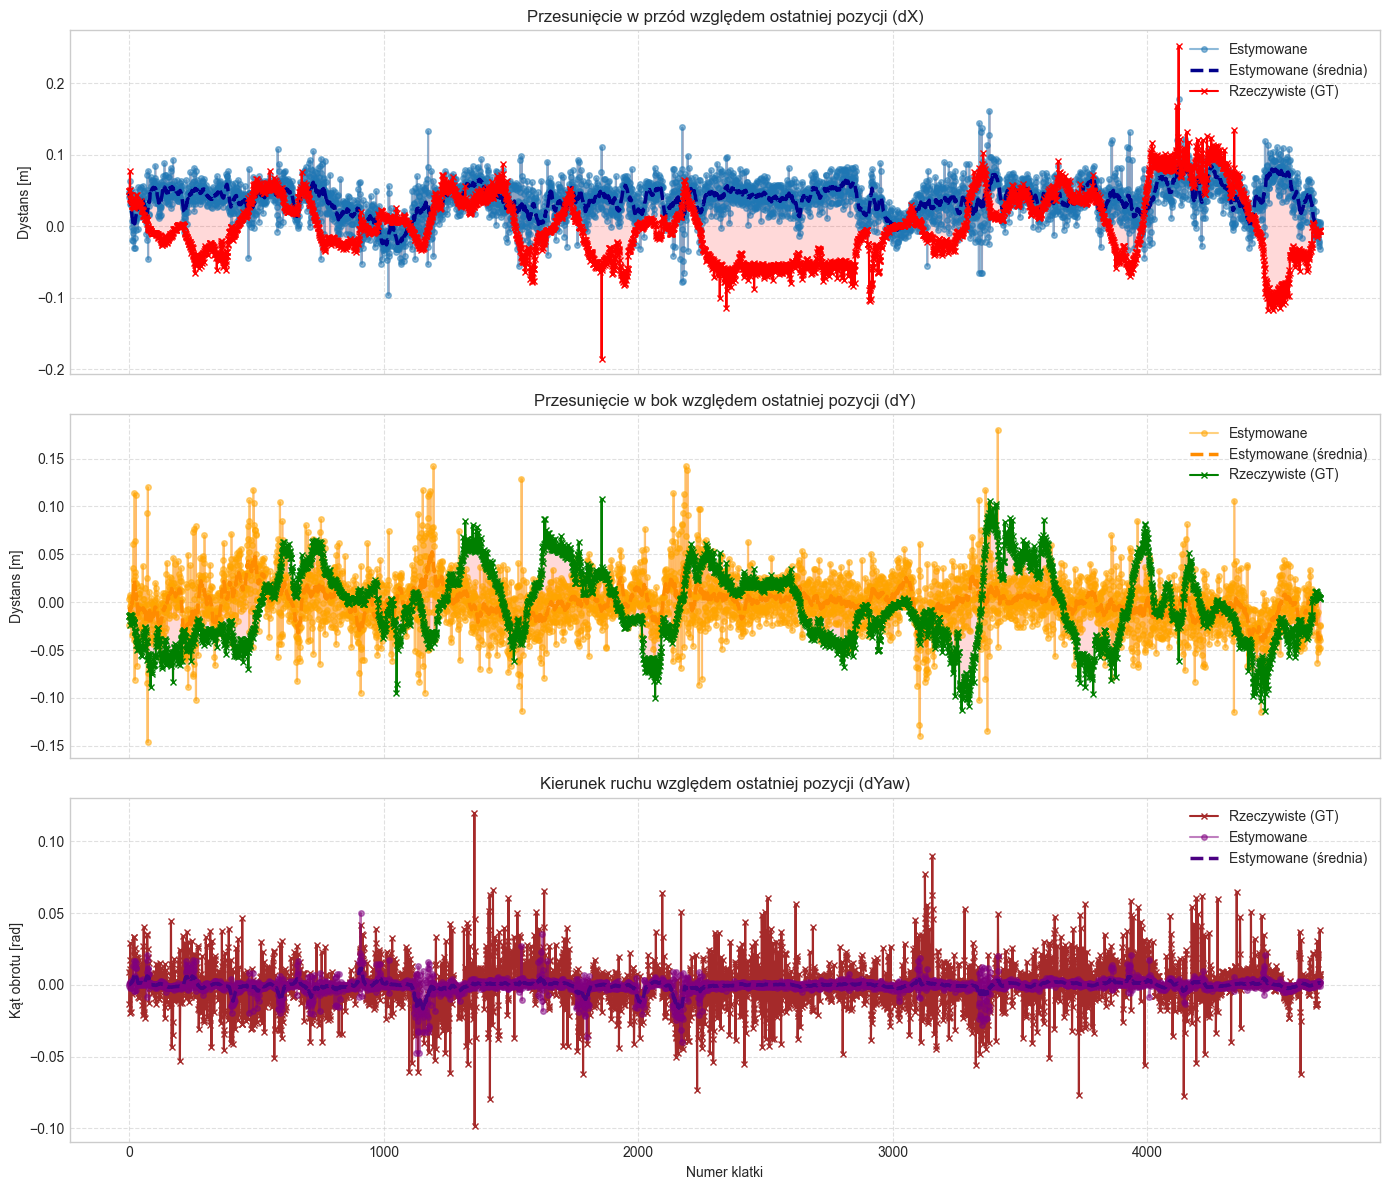

In [482]:
step_pred_dx = traj[0]['step_pred_dx'].iloc[start:end]
step_pred_dy = traj[0]['step_pred_dy'].iloc[start:end]
step_pred_dtheta = traj[0]['step_pred_dtheta'].iloc[start:end]

step_gt_dx = traj[0]['step_gt_dx'].iloc[start:end]
step_gt_dy = traj[0]['step_gt_dy'].iloc[start:end]
step_gt_dtheta = traj[0]['step_gt_dtheta'].iloc[start:end]

# --- OBLICZANIE TRENDU (ŚREDNIA KROCZĄCA) ---
window_size = 15  # <--- ZMIEŃ TĘ WARTOŚĆ: im większa, tym gładsza linia trendu

# Używamy min_periods=1, żeby wykres nie był pusty na początku/końcu (gdzie brakuje pełnego okna)
trend_pred_dx = step_pred_dx.rolling(window=window_size, center=True, min_periods=1).mean()
trend_pred_dy = step_pred_dy.rolling(window=window_size, center=True, min_periods=1).mean()
trend_pred_dtheta = step_pred_dtheta.rolling(window=window_size, center=True, min_periods=1).mean()

# --- OBLICZANIE I WYPISYWANIE STATYSTYK BŁĘDU ---

# Zwykły błąd (do odchylenia standardowego)
err_dx = step_pred_dx - step_gt_dx
err_dy = step_pred_dy - step_gt_dy
err_dtheta = step_pred_dtheta - step_gt_dtheta

# Błąd bezwzględny (do średniej i mediany - MAE)
abs_err_dx = np.abs(err_dx)
abs_err_dy = np.abs(err_dy)
abs_err_dtheta = np.abs(err_dtheta)

print("=" * 50)
print("STATYSTYKI BŁĘDU KROKOWEGO (PER STEP):")
print("=" * 50)
print(f"Oś dX (Przesunięcie w przód):")
print(f"  Średnia (MAE) : {abs_err_dx.mean():.5f} m")
print(f"  Mediana       : {abs_err_dx.median():.5f} m")
print(f"  Odchyl. (STD) : {err_dx.std():.5f} m\n")

print(f"Oś dY (Przesunięcie bocznie):")
print(f"  Średnia (MAE) : {abs_err_dy.mean():.5f} m")
print(f"  Mediana       : {abs_err_dy.median():.5f} m")
print(f"  Odchyl. (STD) : {err_dy.std():.5f} m\n")

print(f"Oś dYaw (Kąt obrotu):")
print(f"  Średnia (MAE) : {abs_err_dtheta.mean():.5f} rad")
print(f"  Mediana       : {abs_err_dtheta.median():.5f} rad")
print(f"  Odchyl. (STD) : {err_dtheta.std():.5f} rad")
print("=" * 50)

# --- WYKRESY ---

fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
frames_num = np.arange(traj[0]['frame_id'].iloc[start:end].shape[0])

# dTX
axs[0].plot(frames_num, -step_pred_dx, label='Estymowane', marker='o', markersize=4, alpha=0.5)
axs[0].plot(frames_num, -trend_pred_dx, label=f'Estymowane (średnia)', color='darkblue', linewidth=2.5, linestyle='--')
axs[0].plot(frames_num, step_gt_dx, label='Rzeczywiste (GT)', marker='x', markersize=4, color='red')
axs[0].fill_between(frames_num, -step_pred_dx, step_gt_dx, color='red', alpha=0.15)
axs[0].set_ylabel('Dystans [m]')
axs[0].set_title('Przesunięcie w przód względem ostatniej pozycji (dX)')
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# dTY
axs[1].plot(frames_num, step_pred_dy, label='Estymowane', marker='o', markersize=4, color='orange', alpha=0.5)
axs[1].plot(frames_num, trend_pred_dy, label=f'Estymowane (średnia)', color='darkorange', linewidth=2.5, linestyle='--')
axs[1].plot(frames_num, step_gt_dy, label='Rzeczywiste (GT)', marker='x', markersize=4, color='green')
axs[1].fill_between(frames_num, step_pred_dy, step_gt_dy, color='red', alpha=0.15)
axs[1].set_ylabel('Dystans [m]')
axs[1].set_title('Przesunięcie w bok względem ostatniej pozycji (dY)')
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# dYAW
axs[2].plot(frames_num, step_gt_dtheta, label='Rzeczywiste (GT)', marker='x', markersize=4, color='brown')
axs[2].plot(frames_num, -step_pred_dtheta, label='Estymowane', marker='o', markersize=4, color='purple', alpha=0.5)
axs[2].plot(frames_num, -trend_pred_dtheta, label=f'Estymowane (średnia)', color='indigo', linewidth=2.5, linestyle='--')
axs[2].fill_between(frames_num, -step_pred_dtheta, step_gt_dtheta, color='red', alpha=0.15)
axs[2].set_ylabel('Kąt obrotu [rad]')
axs[2].set_title('Kierunek ruchu względem ostatniej pozycji (dYaw)')
axs[2].set_xlabel('Numer klatki')
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()

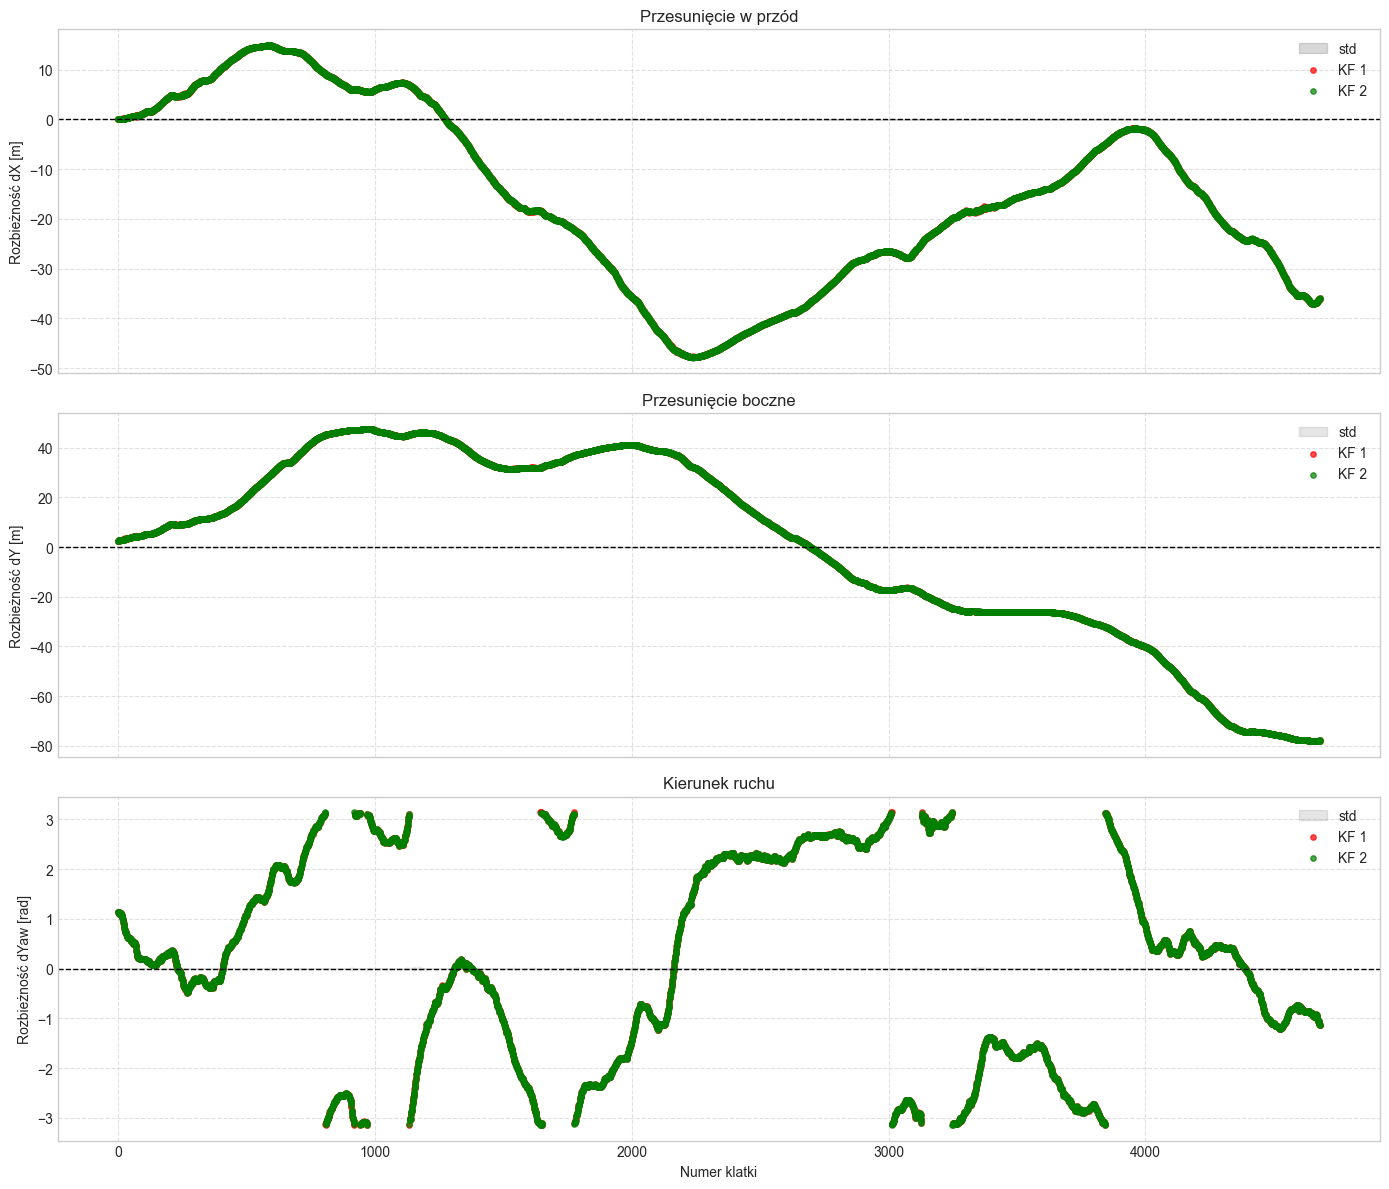

In [480]:
# --- Time window diagnostic data ---

results = traj1.iloc[start:end]
fig, axs = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
frames_num = np.arange(results['frame_id'].shape[0])

# Zdefiniowanie wymiarów
N = len(results)
k = 2
if N > 0:
    idividual_estim = np.full((N, k, 3), np.nan, dtype=float)

    # Parsowanie estymat zapisanych jako string w CSV (format: x,y,th;x,y,th)
    for i, est_str in enumerate(results['individual_estimates_str']):
        
        if pd.isna(est_str) or not str(est_str).strip():
            continue
            
        estimates = str(est_str).split(';')
        m = len(estimates)
        if m > 0:
            limit = min(m, k)
            for j in range(limit):
                vals = estimates[j].split(',')
                if len(vals) == 3:
                    idividual_estim[i, j, 0] = float(vals[0])
                    idividual_estim[i, j, 1] = float(vals[1])
                    idividual_estim[i, j, 2] = float(vals[2])
        
    # Ekstrakcja predykcji do czystych tablic NumPy (wymagane do poprawnego broadcastingu)
    pred_x = results['pred_x'].values
    pred_y = results['pred_y'].values
    pred_theta = results['pred_theta'].values

    # recenter estimates (final predition as a center)
    diff_x = idividual_estim[:, :, 0] - pred_x[:, np.newaxis]
    diff_y = idividual_estim[:, :, 1] - pred_y[:, np.newaxis]

    # protected angles from -pi to pi jump
    diff_theta = np.arctan2(np.sin(idividual_estim[:, :, 2] - pred_theta[:, np.newaxis]),
                            np.cos(idividual_estim[:, :, 2] - pred_theta[:, np.newaxis]))

    # Ekstrakcja odchyleń
    std_x = results['est_std_x'].values
    std_y = results['est_std_y'].values
    std_theta = results['est_std_theta'].values

    # --- Wykres X ---
    # STD
    axs[0].fill_between(frames_num, -std_x, std_x,
                        color='gray', alpha=0.3, label='std')

    # Scatter for each estimate
    color_list= ['red', 'green', 'blue']

    for j in range(k):
        axs[0].scatter(frames_num, diff_x[:, j], label=f'KF {j+1}', color = color_list[j], s=15, alpha=0.7)

    axs[0].set_ylabel('Rozbieżność dX [m]')
    axs[0].set_title('Przesunięcie w przód')
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].axhline(0, color='black', linewidth=1, linestyle='--') # Oś zerowa (finalna predykcja)
    axs[0].legend(loc='upper right')

    # --- Wykres Y ---
    axs[1].fill_between(frames_num, -std_y, std_y,
                        color='gray', alpha=0.2, label='std')
    for j in range(k):
        axs[1].scatter(frames_num, diff_y[:, j], label=f'KF {j+1}', color = color_list[j], s=15, alpha=0.7)

    axs[1].set_ylabel('Rozbieżność dY [m]')
    axs[1].set_title('Przesunięcie boczne')
    axs[1].grid(True, linestyle='--', alpha=0.6)
    axs[1].axhline(0, color='black', linewidth=1, linestyle='--')
    axs[1].legend(loc='upper right')

    # --- Wykres Yaw ---
    axs[2].fill_between(frames_num, -std_theta, std_theta,
                        color='gray', alpha=0.2, label='std')
    for j in range(k):
        axs[2].scatter(frames_num, diff_theta[:, j], label=f'KF {j+1}', color = color_list[j], s=15, alpha=0.7)

    axs[2].set_xlabel('Numer klatki')
    axs[2].set_ylabel('Rozbieżność dYaw [rad]')
    axs[2].set_title('Kierunek ruchu')
    axs[2].grid(True, linestyle='--', alpha=0.6)
    axs[2].axhline(0, color='black', linewidth=1, linestyle='--')
    axs[2].legend(loc='upper right')

    plt.tight_layout()
    plt.show()